# Assignment 6 - Weather trends and anomalies

This analysis uses NASA POWER gridded assimilated estimates for one point at the centroid of the 25 selected Story County fields. These values are not station observations.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
for parent in (ROOT, *ROOT.parents):
    if (parent / 'data/processed/assignment-06/weather_daily.csv').is_file():
        ROOT = parent
        break
DAILY_PATH = ROOT / 'data/processed/assignment-06/weather_daily.csv'
SUMMARY_PATH = ROOT / 'data/processed/assignment-06/weather_summary.json'
PROVENANCE_PATH = ROOT / 'data/provenance/nasa_power_1991_2023.json'
FIGURE_PATH = ROOT / 'docs/assets/weather_trends.png'

## Load and verify the committed weather products

In [2]:
daily = pd.read_csv(DAILY_PATH, parse_dates=['date'])
summary = json.loads(SUMMARY_PATH.read_text())
provenance = json.loads(PROVENANCE_PATH.read_text())

assert len(daily) == 12053
assert daily['date'].min() == pd.Timestamp('1991-01-01')
assert daily['date'].max() == pd.Timestamp('2023-12-31')
assert not daily['date'].duplicated().any()
assert daily['precip_mm'].dropna().ge(0).all()
assert provenance['units'] == {'PRECTOTCORR': 'mm/day', 'T2M': 'C'}

pd.DataFrame({
    'metric': ['Daily records', 'Mean 2023 temperature anomaly (C)', '2023 precipitation (mm)'],
    'value': [summary['record_count'], summary['t2m_anomaly_2023_c'], summary['precip_2023_mm']],
})

,metric,value
0,Daily records,12053.000000
1,Mean 2023 temperature anomaly (C),1.824059
2,2023 precipitation (mm),627.620000


## Method

Temperature is smoothed with a centered seven-day mean. Daily temperature baselines use 1991–2020 values grouped by a leap-aligned calendar index: February 29 has its own group, and March 1 aligns across leap and non-leap years. Temperature anomalies are reported only for 2023.

In [3]:
weather_2023 = daily.loc[daily['date'].dt.year == 2023].copy()
extremes = weather_2023.loc[
    [weather_2023['t2m_anomaly_c'].idxmin(), weather_2023['t2m_anomaly_c'].idxmax()],
    ['date', 't2m_c', 'baseline_t2m_c', 't2m_anomaly_c', 'precip_mm'],
]
extremes

,date,t2m_c,baseline_t2m_c,t2m_anomaly_c,precip_mm
11721,2023-02-03,-16.66,-5.522333,-11.137667,0.00
12045,2023-12-24,9.55,-6.833333,16.383333,9.93


## Temperature, precipitation, and 2023 anomaly

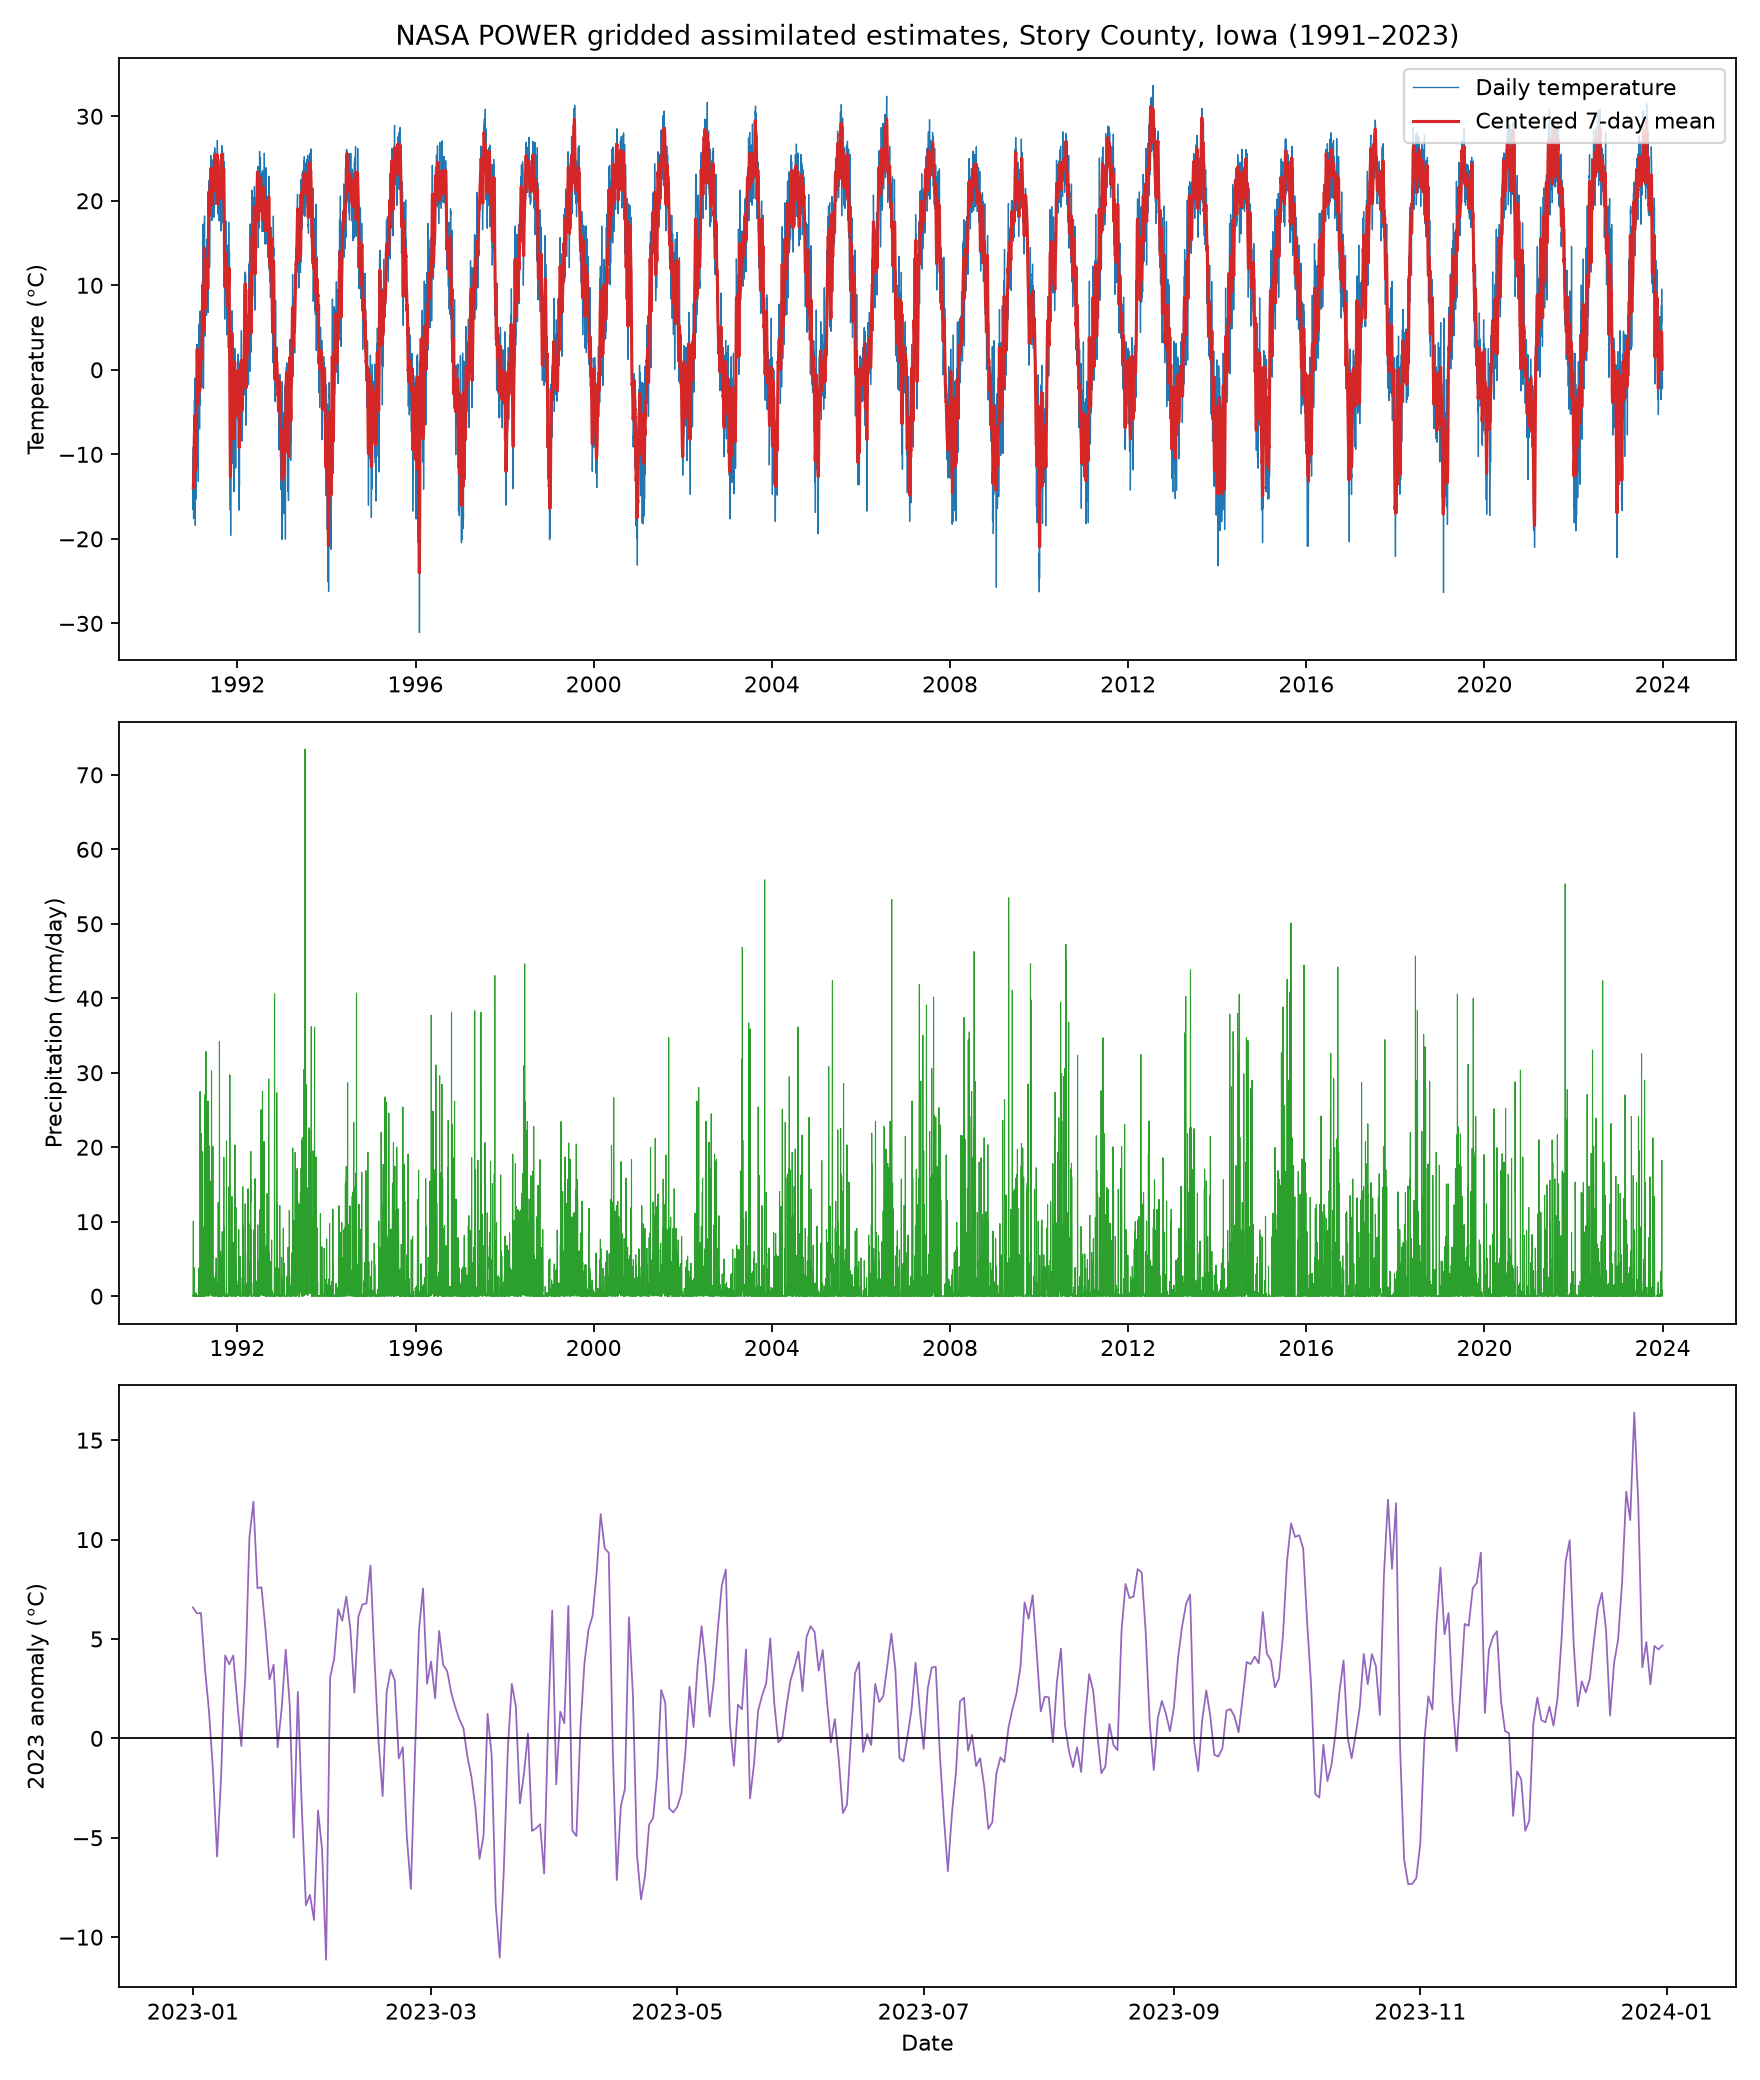

In [4]:
display(Image(filename=str(FIGURE_PATH)))

## Interpretation and limitations

The first panel shows daily temperature and its centered seven-day mean; the second shows daily precipitation; the third isolates the 2023 temperature anomaly relative to the 1991–2020 calendar-day baseline. Because NASA POWER provides a single-point gridded assimilated estimate, the series represents the broader grid cell around the field centroid and should not be treated as an on-field weather-station record.